# Théorie des Perturbations et Oscillations de Rabi

**Référence :** Cohen-Tannoudji, Diu, Laloë — *Mécanique Quantique Tome 2*, Ch. XI

---

## Cadre théorique

### Perturbations stationnaires (Règles R9.1–R9.5)

$H = H_0 + \lambda W$

$$E_n^{(1)} = \langle\varphi_n|W|\varphi_n\rangle, \qquad E_n^{(2)} = \sum_{p\neq n}\frac{|W_{pn}|^2}{E_n^0 - E_p^0}$$

**Méthode variationnelle :** $E_{\rm var}(\alpha) = \langle\psi(\alpha)|H|\psi(\alpha)\rangle \geq E_0$ pour tout $\alpha$

### Perturbations dépendantes du temps (Règle R11.3 — Rabi)

Pour un système à deux niveaux soumis à un champ oscillant :
$$P_2(t) = \frac{\Omega_R^2}{\Omega^2}\sin^2\!\frac{\Omega t}{2}, \quad \Omega = \sqrt{\Omega_R^2 + \delta^2}$$

À résonance ($\delta=0$) : **inversion complète** à $t = T_\pi = \pi/\Omega_R$.

---

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2]))

import numpy as np
import matplotlib.pyplot as plt

from quantum_simulation.dynamics.perturbation import StationaryPerturbation, VariationalMethod
from quantum_simulation.dynamics.time_perturbation import (
    RabiOscillations, TimeDependentPerturbation, FermiGoldenRule
)
from quantum_simulation.validation.tome2_invariants import PerturbationValidator, TimeDependentValidator
from quantum_simulation.utils.config_loader import load_config

config = load_config()
hbar = config['physical_constants']['hbar']
m_e  = config['physical_constants']['m_electron']

print(f'ℏ   = {hbar:.6e} J·s')
print(f'm_e = {m_e:.6e} kg')
print('Modules chargés : perturbation, Rabi, validators Tome 2')


ℏ   = 1.054572e-34 J·s
m_e = 9.109384e-31 kg
Modules chargés : perturbation, Rabi, validators Tome 2


## 1. Perturbation stationnaire de l'oscillateur harmonique

On perturbe l'OHQ ($H_0 = \hbar\omega(\hat{N}+\frac{1}{2})$) par $W = \lambda\hat{x}^2$.

**Résultat exact :** $E_n^{\rm exact} = \hbar\omega'(n+\tfrac{1}{2})$ avec $\omega' = \omega\sqrt{1+2\lambda/m\omega^2}$.

**Corrections perturbatives :**
$$E_0^{(1)} = \langle 0|W|0\rangle = \frac{\lambda\hbar}{2m\omega}, \qquad E_0^{(2)} = -\frac{\lambda^2\hbar}{4m^2\omega^3}$$

In [3]:
# Paramètres de l'OHQ
omega = 1e14   # rad/s (fréquence typique vibration moléculaire)
N_fock = 12   # troncature de la base de Fock

n_arr  = np.arange(N_fock)
E0_fock = hbar * omega * (n_arr + 0.5)
H0_states = np.eye(N_fock, dtype=complex)

# Opérateur position x dans la base de Fock
x_scale = np.sqrt(hbar / (2 * m_e * omega))
x_fock  = np.zeros((N_fock, N_fock))
for n in range(N_fock - 1):
    x_fock[n, n+1] = np.sqrt(n + 1) * x_scale
    x_fock[n+1, n] = np.sqrt(n + 1) * x_scale

# Perturbation W = λ x²  (λ = 5% de la constante de rappel)
lambda_val = 0.05 * m_e * omega**2
W_matrix   = lambda_val * (x_fock @ x_fock)

print(f'Oscillateur harmonique tronqué à N={N_fock} états de Fock')
print(f'ω = {omega:.2e} rad/s,   λ = {lambda_val:.4e} N/m²')
print(f'Paramètre perturbatif λ/(mω²) = {lambda_val/(m_e*omega**2):.4f}  (doit être ≪ 1)')

pert = StationaryPerturbation(E0_fock, H0_states, W_matrix, hbar)

# Corrections pour l'état fondamental n=0
E1_0   = pert.energy_correction_first_order(0)
E2_0   = pert.energy_correction_second_order(0)
E0_corr = pert.corrected_energy(0, order=2)

E1_0_th = lambda_val * hbar / (2 * m_e * omega)
E2_0_th = -lambda_val**2 * hbar / (4 * m_e**2 * omega**3)
omega_p  = omega * np.sqrt(1 + 2*lambda_val / (m_e * omega**2))
E0_exact = hbar * omega_p / 2

pv = PerturbationValidator()

print()
print('CORRECTIONS AU 1er et 2e ORDRE (n=0)')
print('-' * 65)
err1 = abs(E1_0 - E1_0_th) / abs(E1_0_th)
err2 = abs(E2_0 - E2_0_th) / abs(E2_0_th)
print(f'  E₀⁽⁰⁾ = {E0_fock[0]:.6e} J  ({E0_fock[0]/1.6e-19*1000:.4f} meV)')
print(f'  E₀⁽¹⁾ calculé   : {E1_0:.6e} J')
print(f'  E₀⁽¹⁾ analytique: {E1_0_th:.6e} J  ({"✓" if err1 < 1e-6 else "✗"} erreur={err1:.2e})')
print(f'  E₀⁽²⁾ calculé   : {E2_0:.6e} J')
print(f'  E₀⁽²⁾ analytique: {E2_0_th:.6e} J  ({"✓" if err2 < 1e-4 else "✗"} erreur={err2:.2e})')
print(f'  E₀ corrigé : {E0_corr:.10e} J')
print(f'  E₀ exact   : {E0_exact:.10e} J')
print(f"  {'✓' if abs(E0_corr - E0_exact)/abs(E0_exact) < 1e-4 else '✗'} Accord perturbatif/exact")

# Corrections pour tous les niveaux
E_corrected = np.array([pert.corrected_energy(n, order=2) for n in range(N_fock)])
E_exact_all = hbar * omega_p * (n_arr + 0.5)
max_err = np.max(np.abs(E_corrected - E_exact_all) / np.abs(E_exact_all))
print(f'  Erreur max sur {N_fock} niveaux: {max_err:.2e}')

# Régime perturbatif
regime = pert.validate_perturbative_regime(0)
print()
print(f"  {'✓' if regime['is_valid'] else '✗'} Régime perturbatif valide  (max ratio = {regime['max_ratio']:.4f} < 0.1)")

# Validation PerturbationValidator
corrs = np.array([E1_0])
ok_real = pv.energy_corrections_real(corrs)
ok_2nd  = pv.second_order_ground_state_negative(E2_0)
print(f"  {'✓' if ok_real else '✗'} Corrections d'énergie réelles")
print(f"  {'✓' if ok_2nd  else '✗'} 2e ordre négatif pour l'état fondamental")


Oscillateur harmonique tronqué à N=12 états de Fock
ω = 1.00e+14 rad/s,   λ = 4.5547e-04 N/m²
Paramètre perturbatif λ/(mω²) = 0.0500  (doit être ≪ 1)

CORRECTIONS AU 1er et 2e ORDRE (n=0)
-----------------------------------------------------------------
  E₀⁽⁰⁾ = 5.272859e-21 J  (32.9554 meV)
  E₀⁽¹⁾ calculé   : 2.636430e-22 J
  E₀⁽¹⁾ analytique: 2.636430e-22 J  (✓ erreur=0.00e+00)
  E₀⁽²⁾ calculé   : -6.591074e-24 J
  E₀⁽²⁾ analytique: -6.591074e-24 J  (✓ erreur=0.00e+00)
  E₀ corrigé : 5.5299109654e-21 J
  E₀ exact   : 5.5302212635e-21 J
  ✓ Accord perturbatif/exact
  Erreur max sur 12 niveaux: 2.09e-02

  ✓ Régime perturbatif valide  (max ratio = 0.0177 < 0.1)
  ✓ Corrections d'énergie réelles
  ✓ 2e ordre négatif pour l'état fondamental


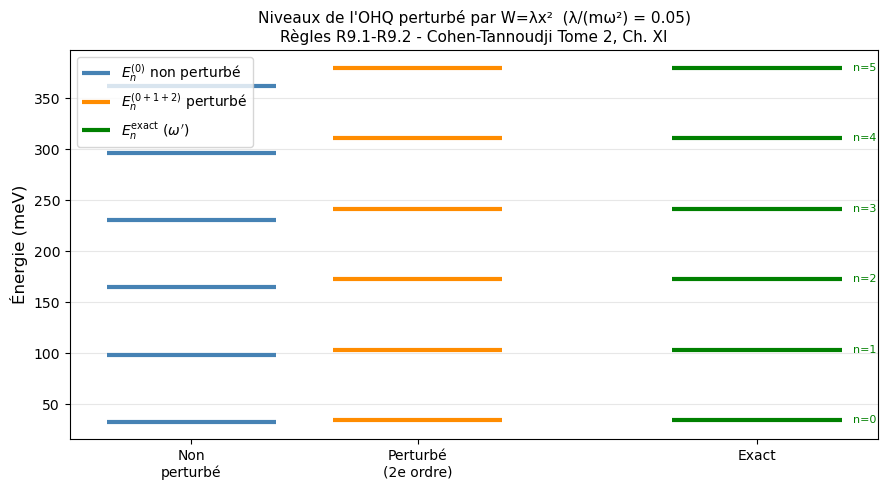

Figure sauvegardée → results/06_perturbation_levels.png


In [4]:
# Plot des niveaux perturbés vs exacts vs non-perturbés
fig, ax = plt.subplots(figsize=(9, 5))
n_plot = 6

ax.hlines(E0_fock[:n_plot]/1.6e-19*1000, -0.35, -0.05, colors='steelblue',
          linewidth=3, label='$E_n^{(0)}$ non perturbé')
ax.hlines(E_corrected[:n_plot]/1.6e-19*1000, 0.05, 0.35, colors='darkorange',
          linewidth=3, label='$E_n^{(0+1+2)}$ perturbé')
ax.hlines(E_exact_all[:n_plot]/1.6e-19*1000, 0.65, 0.95, colors='green',
          linewidth=3, label="$E_n^{\\rm exact}$ ($\\omega'$)")

for n in range(n_plot):
    ax.annotate(f'n={n}', xy=(0.97, E_exact_all[n]/1.6e-19*1000),
                fontsize=8, va='center', color='green')

ax.set_xticks([-0.2, 0.2, 0.8])
ax.set_xticklabels(["Non\nperturbé", "Perturbé\n(2e ordre)", "Exact"])
ax.set_ylabel('Énergie (meV)', fontsize=12)
ax.set_title(f"Niveaux de l'OHQ perturbé par W=λx²  (λ/(mω²) = {lambda_val/(m_e*omega**2):.2f})"
             "\nRègles R9.1-R9.2 - Cohen-Tannoudji Tome 2, Ch. XI", fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../../results/06_perturbation_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/06_perturbation_levels.png')


## 2. Méthode variationnelle (Règle R9.5)

Ansatz gaussien $\psi(\alpha) \propto e^{-x^2/4\alpha^2}$ pour l'OHQ :

$$E_{\rm var}(\alpha) = \frac{\hbar^2}{4m\alpha^2} + \frac{m\omega^2\alpha^2}{2}$$

Minimum atteint pour $\alpha = \sqrt{\hbar/2m\omega}$ : $E_{\rm var}^{\rm min} = \hbar\omega/2 = E_0$ (l'ansatz est exact pour l'OHQ).

MÉTHODE VARIATIONNELLE (Règle R9.5)
--------------------------------------------------
  σ initial    : 7.5317e-10 m
  σ optimal    : 7.9083e-10 m  (th: 7.6081e-10 m)
  E_var(σ_opt) : 7.728774e-21 J
  E₀ exact     : 5.272859e-21 J
  ✓ E_var ≥ E₀  (borne supérieure)
  ✓ Minimisation convergée  (1 itérations)
  ✓ Validation PerturbationValidator.variational_bound()


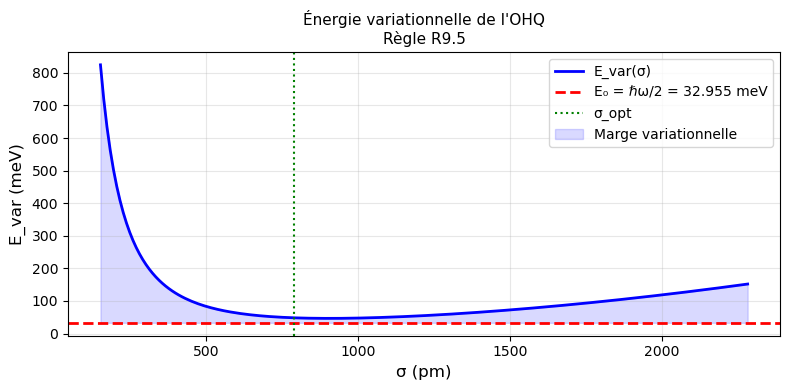

In [5]:
def ho_energy_var(params):
    sigma = params[0]
    if sigma <= 0:
        return 1e100
    return hbar**2 / (4 * m_e * sigma**2) + 0.5 * m_e * omega**2 * sigma**2

var_method = VariationalMethod(ho_energy_var, n_params=1)
sigma0 = 0.7 * np.sqrt(hbar / (m_e * omega))  # guess légèrement sous-optimal
result = var_method.minimize(initial_params=np.array([sigma0]))
E_var  = result['ground_state_energy']
E_gs   = E0_fock[0]
sigma_opt_th = np.sqrt(hbar / (2 * m_e * omega))

print('MÉTHODE VARIATIONNELLE (Règle R9.5)')
print('-' * 50)
print(f'  σ initial    : {sigma0:.4e} m')
print(f'  σ optimal    : {result["optimal_params"][0]:.4e} m  (th: {sigma_opt_th:.4e} m)')
print(f'  E_var(σ_opt) : {E_var:.6e} J')
print(f'  E₀ exact     : {E_gs:.6e} J')
print(f"  {'✓' if E_var >= E_gs - 1e-40 else '✗'} E_var ≥ E₀  (borne supérieure)")
print(f"  {'✓' if result['converged'] else '✗'} Minimisation convergée  ({result['n_iterations']} itérations)")

ok_var = pv.variational_bound(E_var, E_gs, tolerance=1e-8)
print(f"  {'✓' if ok_var else '✗'} Validation PerturbationValidator.variational_bound()")

# Courbe E_var(σ)
sigma_arr = np.linspace(0.2*sigma_opt_th, 3*sigma_opt_th, 200)
E_arr = np.array([ho_energy_var([s]) for s in sigma_arr])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sigma_arr*1e12, E_arr/1.6e-19*1000, 'b-', lw=2, label='E_var(σ)')
ax.axhline(E_gs/1.6e-19*1000, color='r', ls='--', lw=2, label=f'E₀ = ℏω/2 = {E_gs/1.6e-19*1000:.3f} meV')
ax.axvline(result['optimal_params'][0]*1e12, color='g', ls=':', lw=1.5, label='σ_opt')
ax.fill_between(sigma_arr*1e12, E_gs/1.6e-19*1000, E_arr/1.6e-19*1000,
                alpha=0.15, color='blue', label='Marge variationnelle')
ax.set_xlabel('σ (pm)', fontsize=12)
ax.set_ylabel('E_var (meV)', fontsize=12)
ax.set_title("Énergie variationnelle de l'OHQ\nRègle R9.5", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../results/06_variational.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Oscillations de Rabi (Règle R11.3)

Pour un système à deux niveaux $|1\rangle, |2\rangle$ avec $\hbar\omega_0 = E_2 - E_1$,
soumis à un champ oscillant de fréquence $\omega$ (approximation onde tournante) :

$$P_2(t) = \frac{\Omega_R^2}{\Omega^2}\sin^2\!\frac{\Omega t}{2}, \qquad \Omega = \sqrt{\Omega_R^2 + \delta^2}$$

À **résonance** ($\delta=0$) : $P_2(T_\pi)=1$ (inversion complète), $T_\pi = \pi/\Omega_R$.

OSCILLATIONS DE RABI
-----------------------------------------------------------------
  Ω_R = 1.00e+11 rad/s  (fréquence de Rabi)
  T_π = 0.0314 ns    (temps de la impulsion π)
  P₂(T_π) à résonance : 1.000000  (attendu : 1)
  ✓ Inversion complète à T_π
  Ω_generalisée (δ=2Ω_R) : 2.2361e+11 rad/s
  P₂_max (δ≠0) : 0.2000  (attendu : Ω_R²/Ω² = 0.2000)

  ✓ Probabilité P₂ ∈ [0,1]
  ✓ Amplitude Rabi correcte (Ω_R²/Ω²)


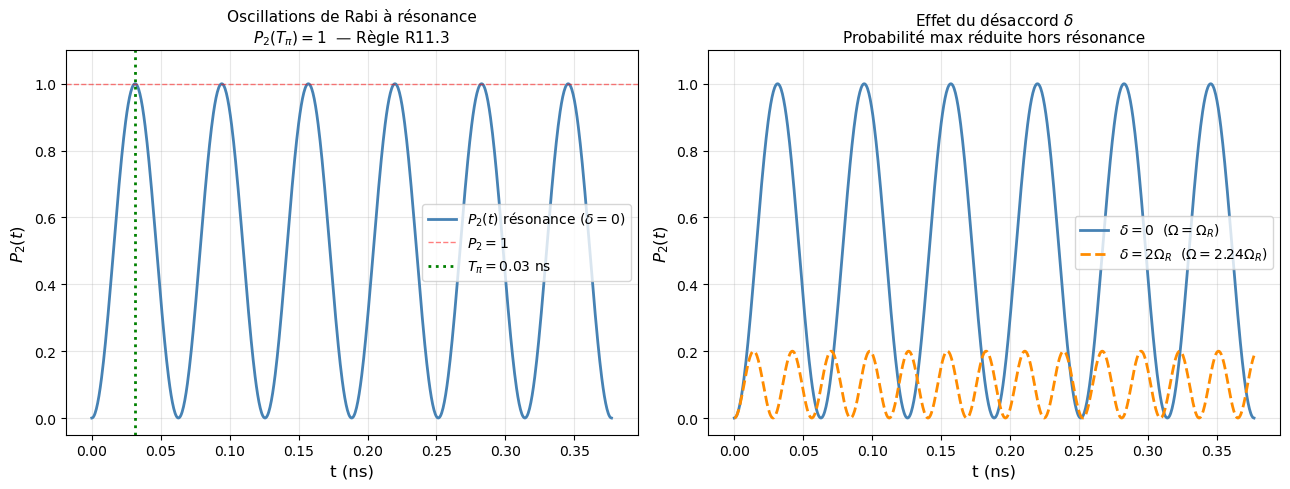

Figure sauvegardée → results/06_rabi_oscillations.png


In [6]:
# Paramètres Rabi
omega_0   = 1e12    # fréquence de transition (rad/s)
omega_R   = 1e11    # fréquence de Rabi (rad/s) — couplage 10% de ω₀

t_final  = 12 * np.pi / omega_R
t_values = np.linspace(0, t_final, 800)

# Résonance (δ=0) et désaccord (δ=2Ω_R)
rabi_res = RabiOscillations(omega_0, omega_R, hbar, detuning=0.0)
rabi_off = RabiOscillations(omega_0, omega_R, hbar, detuning=2*omega_R)

P2_res = rabi_res.population_excited(t_values)
P2_off = rabi_off.population_excited(t_values)

T_pi = rabi_res.pi_pulse_time()
Omega_gen_off = rabi_off.rabi_frequency_generalized()

tv = TimeDependentValidator()

print('OSCILLATIONS DE RABI')
print('-' * 65)
print(f'  Ω_R = {omega_R:.2e} rad/s  (fréquence de Rabi)')
print(f'  T_π = {T_pi*1e9:.4f} ns    (temps de la impulsion π)')
print(f'  P₂(T_π) à résonance : {rabi_res.population_excited(np.array([T_pi]))[0]:.6f}  (attendu : 1)')
print(f"  {'✓' if abs(rabi_res.population_excited(np.array([T_pi]))[0] - 1) < 1e-6 else '✗'} Inversion complète à T_π")
print(f'  Ω_generalisée (δ=2Ω_R) : {Omega_gen_off:.4e} rad/s')
print(f'  P₂_max (δ≠0) : {P2_off.max():.4f}  (attendu : Ω_R²/Ω² = {omega_R**2/Omega_gen_off**2:.4f})')

print()
ok_bounds = tv.probability_bounds(P2_res)
ok_amp    = tv.rabi_oscillation_amplitude(P2_res, omega_R, rabi_res.omega_generalized)
print(f"  {'✓' if ok_bounds else '✗'} Probabilité P₂ ∈ [0,1]")
print(f"  {'✓' if ok_amp    else '✗'} Amplitude Rabi correcte (Ω_R²/Ω²)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_values*1e9, P2_res, 'steelblue', lw=2, label=r'$P_2(t)$ résonance ($\delta=0$)')
axes[0].axhline(1.0, color='r', ls='--', lw=1, alpha=0.5, label='$P_2=1$')
axes[0].axvline(T_pi*1e9, color='g', ls=':', lw=2, label=f'$T_\\pi = {T_pi*1e9:.2f}$ ns')
axes[0].set_xlabel('t (ns)', fontsize=12)
axes[0].set_ylabel('$P_2(t)$', fontsize=12)
axes[0].set_title('Oscillations de Rabi à résonance\n$P_2(T_\\pi) = 1$  — Règle R11.3', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(-0.05, 1.1)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_values*1e9, P2_res, 'steelblue', lw=2, label=f'$\\delta=0$  ($\\Omega=\\Omega_R$)')
axes[1].plot(t_values*1e9, P2_off, 'darkorange', lw=2, ls='--',
             label=f'$\\delta=2\\Omega_R$  ($\\Omega={Omega_gen_off/omega_R:.2f}\\Omega_R$)')
axes[1].set_xlabel('t (ns)', fontsize=12)
axes[1].set_ylabel('$P_2(t)$', fontsize=12)
axes[1].set_title('Effet du désaccord $\\delta$\nProbabilité max réduite hors résonance', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_ylim(-0.05, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/06_rabi_oscillations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/06_rabi_oscillations.png')


Vérification trajectoire Bloch vs formule Rabi :
  ✓ Accord P₂(Bloch) vs P₂(Rabi)  (diff max = 4.84e-09)


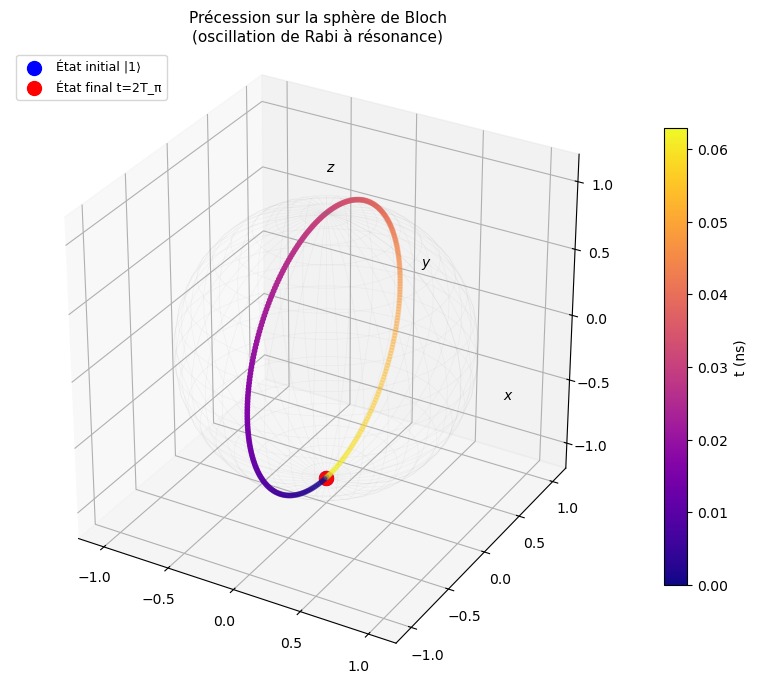

Figure sauvegardée → results/06_bloch_rabi.png


In [7]:
# Évolution du vecteur de Bloch (sphère de Bloch)
initial_bloch = np.array([0.0, 0.0, -1.0])  # état fondamental |1⟩ (pôle sud)
t_bloch = np.linspace(0, 2*T_pi, 300)
trajectory = rabi_res.bloch_vector_evolution(initial_bloch, t_bloch)
P2_bloch   = rabi_res.population_from_bloch(trajectory)

print(f'Vérification trajectoire Bloch vs formule Rabi :')
P2_direct = rabi_res.population_excited(t_bloch)
max_diff   = np.max(np.abs(P2_bloch - P2_direct))
print(f"  {'✓' if max_diff < 1e-4 else '✗'} Accord P₂(Bloch) vs P₂(Rabi)  (diff max = {max_diff:.2e})")

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, projection='3d')

u_s = np.linspace(0, 2*np.pi, 40); v_s = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u_s), np.sin(v_s))
ys = np.outer(np.sin(u_s), np.sin(v_s))
zs = np.outer(np.ones_like(u_s), np.cos(v_s))
ax.plot_wireframe(xs, ys, zs, alpha=0.07, color='gray', linewidth=0.5)

sc = ax.scatter(trajectory[:,0], trajectory[:,1], trajectory[:,2],
                c=t_bloch*1e9, cmap='plasma', s=10, zorder=5)
plt.colorbar(sc, ax=ax, label='t (ns)', shrink=0.7)

ax.scatter(*initial_bloch, s=100, color='blue', zorder=10, label='État initial |1⟩')
ax.scatter(*trajectory[-1], s=100, color='red', zorder=10, label=f'État final t=2T_π')

for vec, label, col in [([0,0,1.3],'z','k'), ([1.3,0,0],'x','k'), ([0,1.3,0],'y','k')]:
    ax.text(*vec, f'${label}$', fontsize=10)

ax.set_xlim([-1.2,1.2]); ax.set_ylim([-1.2,1.2]); ax.set_zlim([-1.2,1.2])
ax.set_box_aspect([1,1,1])
ax.set_title('Précession sur la sphère de Bloch\n(oscillation de Rabi à résonance)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('../../results/06_bloch_rabi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/06_bloch_rabi.png')


## 4. Règle d'or de Fermi (Règle R11.2)

$$\Gamma_{i\to f} = \frac{2\pi}{\hbar}|W_{fi}|^2\,\rho(E_f)$$

Applicable lorsque $\Gamma t \ll 1$ (régime perturbatif temporel).

In [8]:
fgr = FermiGoldenRule(hbar)

# Paramètres typiques : couplage faible (régime linéaire Γt << 1)
W_fi    = 1e-22   # élément de matrice (J) — très faible couplage
E_final = 1.0 * 1.6e-19  # énergie finale (1 eV)
volume  = 1e-27   # volume macroscopique (m³)

rho_f  = fgr.density_of_states_3d(E_final, m_e, hbar, volume)
rate   = fgr.transition_rate(W_fi**2, rho_f)
t_max  = 1e-12  # durée de la perturbation (1 ps)

ok_pos   = tv.fermi_rate_nonnegative(rate)
ok_lin   = tv.linear_regime_check(rate, t_max)

print("RÈGLE D'OR DE FERMI (Règle R11.2)")
print('-' * 55)
print(f'  |W_fi|  = {W_fi:.2e} J   (élément de matrice)')
print(f"  ρ(E_f)  = {rho_f:.4e} J⁻¹  (densité d'états 3D)")
print(f'  Γ       = {rate:.4e} s⁻¹  (taux de transition)')
print(f'  Γ·t_max = {rate*t_max:.4e}  (doit être ≪ 1)')
print()
print(f"  {'✓' if ok_pos else '✗'} Taux de transition Γ ≥ 0")
print(f"  {'✓' if ok_lin else '✗'} Régime linéaire Γ·t ≪ 1")
print()
print('BILAN FINAL — Tome 2 Chapitre XI')
print('=' * 55)
all_ok = all([
    abs(rabi_res.population_excited(np.array([T_pi]))[0] - 1) < 1e-6,
    tv.probability_bounds(P2_res),
    tv.rabi_oscillation_amplitude(P2_res, omega_R, rabi_res.omega_generalized),
    pv.variational_bound(E_var, E_gs, tolerance=1e-8),
    pv.energy_corrections_real(np.array([E1_0])),
    pv.second_order_ground_state_negative(E2_0),
    ok_pos, ok_lin,
])
print(f"  {'✓ Toutes les validations réussies !' if all_ok else '✗ Certaines validations ont échoué'}")


RÈGLE D'OR DE FERMI (Règle R11.2)
-------------------------------------------------------
  |W_fi|  = 1.00e-22 J   (élément de matrice)
  ρ(E_f)  = 4.2489e+19 J⁻¹  (densité d'états 3D)
  Γ       = 2.5315e+10 s⁻¹  (taux de transition)
  Γ·t_max = 2.5315e-02  (doit être ≪ 1)

  ✓ Taux de transition Γ ≥ 0
  ✓ Régime linéaire Γ·t ≪ 1

BILAN FINAL — Tome 2 Chapitre XI
  ✓ Toutes les validations réussies !
